# Data Strategy
### VBZ Tram Zürich — Vom Rohdaten-Archiv zum Master-Datensatz

Dieses Notebook dokumentiert alle strategischen Entscheidungen des Research-Projekts:
Ausgangslage, Probleme, Lösungen und den Weg zum finalen `vbz_master.parquet`.

---

## Big Picture — Die gesamte Datenpipeline

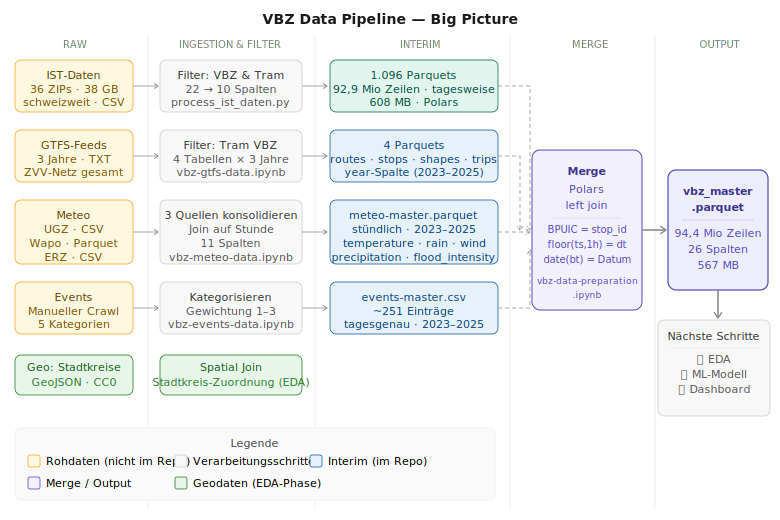

In [1]:
from IPython.display import SVG, display
from pathlib import Path

for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / 'data' / 'raw').exists():
        _svg_path = _p / 'assets' / 'vbz_strategy.svg'
        break

display(SVG(filename=str(_svg_path)))

---

## 1 — Ausgangslage: Welche Daten standen zur Verfügung?

Zürich bietet eine außergewöhnlich gute Open-Data-Landschaft.
Alle relevanten Datensätze sind kostenlos, maschinenlesbar und gut dokumentiert.

| Datenschicht | Quelle | Format | Lizenz | Herausforderung |
| :--- | :--- | :--- | :--- | :--- |
| **IST-Daten** (Verkehr) | archive.opentransportdata.swiss | ZIP / CSV | Eigene NB | 38 GB komprimiert, schweizweit |
| **GTFS** (Fahrplan) | data.stadt-zuerich.ch | ZIP / TXT | CC0 | 3 Jahrgänge, gesamtes ZVV-Netz |
| **Meteo** (Wetter) | data.stadt-zuerich.ch (UGZ, Wapo, ERZ) | CSV / Parquet | CC0 | 3 Quellen, unterschiedliche Auflösung |
| **Events** (Kalender) | Manueller Crawl (Gemini, Perplexity, Transfermarkt) | CSV | Eigene Recherche | Keine strukturierte Quelle verfügbar |
| **Geo** (Stadtkreise) | data.stadt-zuerich.ch | GeoJSON | CC0 | Sofort verwendbar |

> **Scope:** Analysezeitraum **2023–2025**. Ab Mitte 2025 wechselt das IST-Daten-Format auf v2 —
> deshalb bleibt der Scope bei v1 für Einheitlichkeit.

---

## 2 — Was musste verändert werden?

### Warum überhaupt filtern?

Die Rohdaten beschreiben den **gesamten öffentlichen Verkehr der Schweiz** —
jeder Zug, jeder Bus, jede Seilbahn, jedes Schiff. Für dieses Projekt relevant
ist ein sehr spezifischer Ausschnitt. Die folgende Übersicht zeigt transparent,
was wir eingeschränkt haben — und warum.

---

### IST-Daten — Von der Schweiz zu VBZ Tram Zürich

| Filter | Von | Auf | Begründung |
| :--- | :--- | :--- | :--- |
| **Betreiber** | Alle ~400 Transportunternehmen CH | `BETREIBER_ID = 85:3849` (VBZ) | Nur der städtische Betreiber Zürich ist relevant |
| **Produkt** | Zug, Bus, Tram, Schiff, Seilbahn … | `PRODUKT_ID = Tram` | Tram fährt im offenen Stadtverkehr — mehr Einflussfaktoren als Zug oder Bus |
| **Zeitraum** | Archiv ab 2016 verfügbar | 2023–2025 | 3 vollständige Jahre, einheitliches Datenformat v1 |
| **Format** | Ab Mitte 2025: Format v2 | Nur v1 | Unterschiedliche Schemas würden den Merge verkomplizieren |
| **Messstatus** | REAL, GESCHÄTZT, PROGNOSE, UNBEKANNT | Nur `REAL` (beide Richtungen) | Nur echte GPS-Messungen — keine Schätzungen oder Prognosewerte |
| **Durchfahrten** | `DURCHFAHRT_TF = true/false` | Nur `false` | Haltestellen ohne Halt sind für Verspätungsanalyse nicht relevant |
| **Zusatzfahrten** | `ZUSATZFAHRT_TF = true/false` | Nur `false` | Ungeplante Fahrten verfälschen den Soll-Ist-Vergleich |
| **Ausfälle** | Würden durch REAL-Filter entfallen | Explizit wieder hinzugefügt | `FAELLT_AUS_TF = true` ist der extremste Verspätungsfall — bewusst behalten |
| **Spalten** | 21 Felder | 8 Felder | Nur Felder mit Analyserelevanz behalten |
| **Geografie** | Schweizweit | Implizit Zürich | Folgt aus VBZ-Filter |

> **Ergebnis:** ~11% der Zeilen wurden entfernt — Durchfahrten, Zusatzfahrten
> und nicht-REAL Messungen. Die verbleibenden Daten sind echte, planmäßige
> Halte mit GPS-bestätigten Zeitstempeln — plus alle Ausfälle.

**Entfernte Spalten** (redundant oder nicht relevant für diesen Scope):

| Spalte | Grund |
| :--- | :--- |
| `BETREIBER_ABK`, `BETREIBER_NAME` | Nach Filter konstant = VBZ |
| `FAHRT_BEZEICHNER` | Technische ID, nicht für Analyse benötigt |
| `UMLAUF_ID` | Fahrzeug-Umlauf, kein EDA-Feature in MVP |
| `VERKEHRSMITTEL_TEXT` | Nach Filter konstant = Tram |
| `PRODUKT_ID` | Nach Filter konstant = Tram |
| `ZUSATZFAHRT_TF` | Zu selten, Randfall |
| `AN_PROGNOSE_STATUS` | Qualitäts-Flag — wird in EDA als Filter genutzt, nicht als Feature |
| `AB_PROGNOSE_STATUS` | s.o. |
| `DURCHFAHRT_TF` | Für Verspätungsanalyse nicht relevant |
| `SLOID` | Kanten-ID, nicht benötigt |
| `LINIEN_ID` | Technische ID — `LINIEN_TEXT` (Kundennummer) reicht |
| `HALTESTELLEN_NAME` | Kommt via GTFS-Join aus `stop_name` — kein Duplikat |

> **Nicht verworfen, bewusst behalten:** `FAELLT_AUS_TF` — Ausfälle sind der
> extremste Verspätungsfall und müssen im Modell abgebildet werden.

---

### GTFS — Von ZVV-Gesamtnetz zu VBZ Tram

| Filter | Von | Auf | Begründung |
| :--- | :--- | :--- | :--- |
| **Betreiber** | Gesamtes ZVV-Netz (S-Bahn, Bus, Tram …) | VBZ Tram-Linien | Konsistenz mit IST-Daten |
| **Referenzjahr** | 2023, 2024, 2025 | 2024 als Primärreferenz | Stabilstes vollständiges Jahr; Netzstruktur ändert sich kaum |
| **Tabellen** | 10+ GTFS-Dateien | 4 Parquets (routes, stops, shapes, trips) | Nur die für Join und Visualisierung benötigten Tabellen |

---

### Meteo — Von allen Stationen zu zwei Referenzpunkten

| Filter | Von | Auf | Begründung |
| :--- | :--- | :--- | :--- |
| **Stationen** | Alle Messstationen Stadt und Kanton Zürich | Stampfenbachstrasse + Mythenquai | Zwei Punkte decken unterschiedliche Topografien ab (Stadtlage vs. Seelage) |
| **Zeitraum** | Seit 1988 (UGZ) / seit 2007 (Wapo) | 2023–2025 | Konsistenz mit IST-Daten-Scope |
| **Auflösung** | Verschiedene (Minuten, Stunden, Tage) | Stündlich konsolidiert | Passend zu den Tram-Zeitstempeln — `floor(1h)` als Join-Schlüssel |

> **Bewusste Einschränkung:** Wir nehmen **nicht** alle Stationen im Netz.
> Zwei Stationen sind für den MVP ausreichend — in v1.3 kann das Modell
> um weitere Stationen erweitert werden.

---

### Events — Schwellenwert und Geografie

| Filter | Von | Auf | Begründung |
| :--- | :--- | :--- | :--- |
| **Besucherzahl** | Alle öffentlichen Veranstaltungen | > 1.000 Besucher | Unterhalb dieser Schwelle kein messbarer Einfluss auf das Tramnetz |
| **Geografie** | Kanton Zürich und Umgebung | Stadt Zürich | Nur Events im VBZ-Einzugsgebiet sind relevant |
| **Zeitraum** | — | 2023–2025 | Konsistenz mit Scope |
| **Datenquelle** | Kein strukturierter Open-Data-Feed | Manueller Crawl | Keine maschinenlesbare Quelle für Zürcher Events verfügbar |

---

### Was wir **nicht** eingeschränkt haben — bewusst

| Datenpunkt | Begründung |
| :--- | :--- |
| **Alle Tageszeiten** | Nacht- und Wochenendfahrten können als Baseline wichtig sein |
| **Alle Tram-Linien** | Keine Vorauswahl — Hotspot-Analyse soll zeigen welche Linien auffällig sind |
| **Ausgefallene Fahrten** | `FAELLT_AUS_TF = true` bleibt drin — extremster Verspätungsfall |
| **Alle Wetterbedingungen** | Auch Schönwetter-Tage sind wichtig als Baseline |
| **2025** | Komplett erhalten als Test-Set — wird erst beim Modell angefasst |

---

## 3 — Grundlegende Entscheidungen

### Polars statt Pandas für die IST-Daten

Bei 88 Mio Zeilen war Pandas an der Grenze des Machbaren.
Ein Benchmark auf den echten Daten hat die Entscheidung getroffen:

| | Pandas | Polars | Faktor |
| :--- | ---: | ---: | ---: |
| Ladezeit (alle Parquets) | 25,7s | 6,6s | 4× schneller |
| RAM-Verbrauch | 6,1 GB | ~1,4 GB | 4× sparsamer |

**Entscheidung:** Polars für alle großen Operationen (IST-Daten, Merge).
Pandas bleibt für kleine Datensätze (GTFS, Meteo, Events) und als Lernreferenz.

```python
pl.from_pandas(df)   # Pandas → Polars
df.to_pandas()       # Polars → Pandas
```

### Left Join überall

Jede Tram-Fahrt bleibt erhalten — fehlende Werte (Sensor-Ausfall, Event-freier Tag)
werden `null` statt die Zeile zu löschen. Datenverlust durch Join ist der häufigste
stille Bug in Merge-Pipelines.

### Scope: 2023–2025, nur v1-Format

Ab Mitte 2025 wechselt opentransportdata.swiss auf Datenformat v2.
Um einheitliche Daten zu haben: Scope ist 2023 bis Ende 2025 im v1-Format.
2026 und v2 sind für eine spätere Iteration vorgesehen.

### Tagesweise Parquets statt einem großen File

~1.035 einzelne Parquets (ein pro Tag) statt einer großen Datei.
Vorteil: einzelne Tage können nachgeladen oder ersetzt werden ohne alles neu zu verarbeiten.
Polars liest sie per `scan_parquet('*.parquet')` trotzdem als einen Datensatz ein.

---

## 4 — Weiterer Verlauf: Ideen & offene Entscheidungen

### Stadtkreis-Zuordnung — bereits im Master

> ✅ **Jede Haltestelle hat bereits einen Stadtkreis** (`district_nr`, `district_name`).  
> Die Zuordnung erfolgt via Spatial Join in `vbz-gtfs-data.ipynb` (Punkt-in-Polygon,  
> Stadtkreis-GeoJSON der Stadt Zürich) und ist Teil von `gtfs_stops_lookup.parquet`.  
> Im `vbz_master.parquet` stehen die Felder direkt zur Verfügung — **kein nachträglicher Join in der EDA nötig.**

Stadtkreis-basierte Analysen in der EDA:
- Welche Stadtkreise haben die höchste durchschnittliche Verspätung?
- Gibt es Kreise, die besonders empfindlich auf Events oder Regen reagieren?
- Topographie-Korrelation (Kreis 6/7/8 = Hügellage vs. 1/2/5 = Innenstadt)?

### Mögliche Datenreduktion vor der EDA

| Option | Beschreibung | Vorteil | Nachteil |
| :--- | :--- | :--- | :--- |
| **Nur Stoßzeiten** | z.B. 06:00–09:00 & 16:00–19:00 | Fokus auf relevante Situationen | Verliert Nacht/Wochenende als Baseline |
| **Nur bestimmte Linien** | z.B. Linien 2, 4, 11, 13, 14 (Hauptlinien) | Fokus auf repräsentative Linien | Verliert Randlinien und deren Muster |
| **Stichprobe** | z.B. jeder 5. Tag pro Monat | Schnellere Iteration | Statistisch weniger robust, Muster können fehlen |
| **Bi-Weekly + Event-Whitelist** | Gerade KW als EDA-Sample, Event-Tage immer dabei | Saisonalität erhalten, Events garantiert enthalten | Halbe Datenmenge — gut für explorative Analyse |

```python
# Bi-Weekly Sample für EDA — gleiche Logik wie Split Option D
event_dates = pl.read_csv('data/interim/events-master.csv', separator=';')['Datum']

df_eda = df.filter(
    (pl.col('ANKUNFTSZEIT').dt.week() % 2 == 0) |
    pl.col('BETRIEBSTAG').str.strptime(pl.Date, '%d.%m.%Y').is_in(event_dates)
)
```

> **Empfehlung:** Erst mit vollem Datensatz EDA beginnen.
> Bi-Weekly Sample als schnelles Explorations-Tool wenn Ladezeit stört.

### Feature Engineering (EDA-Phase)

Aus den vorhandenen Spalten entstehen durch Transformation neue Features:

```python
# Aus IST-Daten
AN_DELAY_MIN    = AN_DELAY / 60              # Sekunden → Minuten
IS_CANCELLED    = FAELLT_AUS_TF == 'true'    # Boolean
HOUR            = ANKUNFTSZEIT.dt.hour       # Tageszeit
WEEKDAY         = ANKUNFTSZEIT.dt.weekday    # 0=Mo, 6=So
MONTH           = ANKUNFTSZEIT.dt.month      # Saisonalität

# Aus GTFS (bereits im Master)
DISTRICT        = district_nr                # Stadtkreis 1–12, direkt verfügbar

# Aus Meteo
IS_SNOW         = (temperature < 1.0) & (rain_duration > 0)
RAIN_CATEGORY   = cut(precipitation_mm, bins=[0, 0.1, 2, inf],
                      labels=['kein', 'leicht', 'stark'])
FLOOD_ALERT     = flood_intensity > THRESHOLD  # Schwellenwert aus Verteilung

# Aus Events
HAS_EVENT       = Event_Name.is_not_null()   # Boolean
MAX_EVENT_WEIGHT = Gewichtung.max() per Tag  # bei Multi-Event-Tagen
```

---

## 5 — Train / Validation / Test Split

Der Split wird erst kurz vor dem Modell final entschieden —
das ist eine ML-Entscheidung, keine Wrangling-Entscheidung.
Die Daten bleiben vollständig erhalten, die Aufteilung erfolgt zur Laufzeit.

### Option A — Chronologischer Jahres-Split *(Einstieg)*

```
2023  →  Training
2024  →  Validation
2025  →  Test          ← einmal anfassen, fertig
```

✅ Zeitliche Reihenfolge erhalten — kein Data Leakage  
✅ Jeder Split enthält alle Jahreszeiten  
✅ Einfach, sauber, nachvollziehbar  
⚠️ Modell sieht nur 1 Jahr Training

### Option B — Klassischer 80/20 Split

```
80% zufällig  →  Training
20% zufällig  →  Test
```

✅ Mehr Trainingsdaten  
❌ Zufälliger Split bei Zeitreihendaten → Data Leakage (Modell sieht "die Zukunft")

### Option C — Rolling Window

```
Train: Monat  1–10  →  Test: Monat 11–12
Train: Monat  2–11  →  Test: Monat 12–13
...
```

✅ Simuliert echten Produktionseinsatz  
✅ Robusteste Methode für Zeitreihendaten  
⚠️ Aufwändiger zu implementieren

### Option D — Bi-Weekly Sampling + Event Whitelist ⭐ *(Verfeinerung)*

```
Gerade KW   →  Training
Ungerade KW →  Validation
Event-Tage  →  immer Training (Whitelist)
```

✅ Saisonalität perfekt erhalten  
✅ Event-Tage (Street Parade, FCZ, Züri Fäscht) gezielt im Training  
✅ Kein Data Leakage  
✅ Whitelist jederzeit erweiterbar  

```python
event_dates = pl.read_csv('data/interim/events-master.csv', separator=';')['Datum']

df = df.with_columns(
    pl.col('BETRIEBSTAG').is_in(event_dates).alias('IS_EVENT'),
    (pl.col('ANKUNFTSZEIT').dt.week() % 2).alias('KW_MOD')
)

df_train = df.filter((pl.col('KW_MOD') == 0) | pl.col('IS_EVENT'))
df_val   = df.filter((pl.col('KW_MOD') != 0) & ~pl.col('IS_EVENT'))
```

> **Plan:** Option A für den ersten Modelldurchlauf. Option D als Verfeinerung,
> wenn das Modell auf Event-Tagen schwächelt.

---

## 6 — Nächste Schritte

| Phase | Notebook | Status |
| :--- | :--- | :--- |
| Datenquellen & Bestandsaufnahme | `vbz-data.ipynb` | ✅ |
| Strategie & Entscheidungen | `vbz-data-strategy.ipynb` | ✅ dieses Notebook |
| IST-Daten Download & Filter | `vbz-ist-daten.ipynb` | ✅ |
| Meteo konsolidieren | `vbz-meteo-data.ipynb` | ✅ |
| Events aufbauen | `vbz-events-data.ipynb` | ✅ |
| GTFS aufbereiten | `vbz-gtfs-data.ipynb` | ✅ |
| Geo-Visualisierung & Benchmark | `vbz-geo-*.ipynb` | ✅ |
| **Merge → Master-Datensatz** | **`vbz-data-preparation.ipynb`** | **→ nächster Schritt** |
| EDA & Analyse | `sf_data-analysis/` | 🔜 Woche 2 |
| ML-Modell | `sf_data-analysis/` | 🔜 Woche 3 |
| Dashboard | `sf_data-analysis/` | 🔜 Bonus |

---

## Datenlandschaft — Open Data ÖPNV Stadt Zürich


# Open Data - ÖPNV Stadt Zürich 



## Überblick





Der ÖPNV in Zürich ist zweistufig organisiert:
- **ZVV** (Zürcher Verkehrsverbund) — Dachverband, koordiniert alle Linien
- **VBZ** (Verkehrsbetriebe Zürich) — operativer Betreiber, unser Hauptprotagonist

Für dieses Projekt werden vier Datentypen kombiniert:
Verkehrsdaten (Ist-Daten), Wetterdaten, Geodaten, Verkehrsdaten (GTFS) und Eventdaten.

## Primär Datenquellen



Die Datenquellen priorisiert:
* ÖPNV **Verkehr** Ist-Daten (Archiv)
* ÖPNV **GTFS** Datensets
* Zürich **Meteo** Datensets
* Zürich **Events** Datensets
* Zürich **Geo** Datensets




### IST-Daten (Verkehr)

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| archive.opentransportdata.swiss | Monatliche Archiv-ZIPs 2023–2025, schweizweite Ist-Daten | [→ Archiv](https://archive.opentransportdata.swiss/actual_data_archive.htm) | Eigene NB — kostenlos, Quellenangabe erforderlich |
| opentransportdata.swiss — Cookbook | Dokumentation Datenstruktur und Feldnamen | [→ Cookbook](https://opentransportdata.swiss/de/cookbook/historic-and-statistics-cookbook/actual-data/) | — |


### GTFS-Daten

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| Stadt Zürich OGD — VBZ GTFS | Fahrplandaten VBZ: Haltestellen, Linienverläufe, Shapes, Trips | [→ GTFS](https://data.stadt-zuerich.ch/dataset/vbz_fahrplandaten_gtfs) | CC0 |



### Meteo-Daten

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| Stadt Zürich OGD — UGZ | Stündliche Meteodaten seit 1992: Temperatur, Wind, Regen, Strahlung | [→ UGZ](https://data.stadt-zuerich.ch/dataset/ugz_meteodaten_stundenmittelwerte) | CC0 |
| Stadt Zürich OGD — Wapo | Niederschlag Wetterstationen Wasserschutzpolizei Mythenquai | [→ Wapo](https://data.stadt-zuerich.ch/dataset/sid_wapo_wetterstationen) | CC0 |
| Stadt Zürich OGD — ERZ | Überschwemmungsmeldungen nach Zone | [→ ERZ](https://data.stadt-zuerich.ch/dataset/erz_ent_ueberschwemmungsmeldungen) | CC0 |
| zueriluft.ch — Airmo | Standortinfos und Metadaten der Messstationen | [→ Stationen](https://zueriluft.ch/airmo/frontend/station.php) | — |




### Event-Daten

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| Python `holidays` | Gesetzliche Feiertage Kanton Zürich, automatisch generiert | [→ PyPI](https://pypi.org/project/holidays/) | MIT |
| Gemini (manuell) | Stadtfeste: Züri Fäscht, Street Parade, Silvesterzauber | — | Eigene Recherche |
| Perplexity (manuell) | Konzerte, Fachmessen, Kongresse (>1.000 Besucher) | — | Eigene Recherche |
| Transfermarkt.de (manuell) | Heimspiele FCZ und GCZ, Saisons 2023–2025 | [→ Transfermarkt](https://www.transfermarkt.de) | Proprietär — nur eigene Analyse |


### Geo-Daten

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| Stadt Zürich OGD — Stadtkreise | GeoJSON-Polygone der 12 Stadtkreise (WGS84) | [→ Stadtkreise](https://data.stadt-zuerich.ch/dataset/geo_stadtkreise) | CC0 |







## Weiter Datenquellen




### Allgemein

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| opentransportdata.swiss | Plattform für öV-Daten Schweiz (Portal, APIs, Archiv) | [→ Portal](https://opentransportdata.swiss) | Eigene NB — kostenlos, Quellenangabe erforderlich |
| opendata.swiss | Nationales Dachportal Schweiz — Suche & Verlinkung | [→ Portal](https://opendata.swiss) | — |
| github.com/VerkehrsbetriebeZuerich | Starter-Code und Beispiele VBZ | [→ GitHub](https://github.com/VerkehrsbetriebeZuerich) | — |

### Lizenz-Übersicht

| Lizenz | Gilt für | Bedingung |
| :--- | :--- | :--- |
| **CC0** | Alle Stadt-Zürich-OGD-Datensätze | Freie Nutzung, Quellenangabe empfohlen |
| **Eigene NB** | opentransportdata.swiss | Kostenlos, `opentransportdata.swiss` als Quelle zitieren |
| **MIT** | Python `holidays` | Freie Nutzung, Lizenzdatei beilegen |
| **Proprietär** | Transfermarkt.de | Nur nicht-kommerzielle Eigenanalyse |


### Ausblick: Individualverkehr (v1.3)

| Quelle | Inhalt | Link | Lizenz |
| :--- | :--- | :--- | :--- |
| Stadt Zürich OGD — Verkehrszählung | Induktionsschleifen: Fahrzeugdichte & Geschwindigkeit | [→ Zählung](https://data.stadt-zuerich.ch/dataset/sid_dav_verkehrszaehlung_miv_od2031) | CC0 |

## Daten im Detail

In [2]:
from zh_tram_data.doc_loader import show_doc

### Ist-Daten


---


#### Quellen IST-Daten

| Quelle | Beschreibung | Link | Format |
| :--- | :--- | :--- | :--- |
| **opentransportdata.swiss** | Plattform für öV-Daten Schweiz — Portal & Dokumentation | [Portal](https://opentransportdata.swiss) | Web |
| **archive.opentransportdata.swiss** | Monatliche Archiv-ZIPs 2023–2025, schweizweite Ist-Daten | [Archiv](https://archive.opentransportdata.swiss/actual_data_archive.htm) | ZIP / CSV |
| **Cookbook Ist-Daten** | Offizielle Dokumentation der Datenstruktur & Feldnamen | [Cookbook](https://opentransportdata.swiss/de/cookbook/historic-and-statistics-cookbook/actual-data/) | Web |

#### Lokale Dateipfade IST-Daten

**Rohdaten** werden nicht gespeichert — zu groß (38 GB komprimiert, ~750 GB entpackt).  
Download & Verarbeitung via `src/process_ist_daten.py` oder `vbz-ist-daten-demo.ipynb`.

Die Monatspakete folgen einem einheitlichen Schema:   
https://archive.opentransportdata.swiss/istdaten/{JAHR}/ist-daten-{JAHR}-{MM}.zip



```text
data/raw/ist-daten/                          
├── ist-daten-2023-01.zip
├── ...
├── ist-daten-2023-12.zip
├── ist-daten-2024-01.zip
├── ...
├── ist-daten-2024-12.zip
├── ist-daten-2025-01.zip
├── ...
└── ist-daten-2025-12.zip
```

```text
data/interim/ist-daten/
├── ist_daten_2023-01-01.parquet
├── ist_daten_2023-01-02.parquet
├── ...
└── ist_daten_2025-12-31.parquet   ← 1.096 Dateien gesamt
```

**Ausgabe** (nach Transformation): `data/interim/ist-daten/*.parquet`  
Gefiltert auf `BETREIBER_ID = 85:3849` (VBZ) & `PRODUKT_ID = Tram` — **10 Spalten** (inkl. `trip_id` und `stop_sequence`), **608 MB** gesamt, **92,9 Mio. Zeilen**.

**Hinweis:** Ab Mitte 2025 wechselt das Format auf v2. Deshalb verwenden wir nur bis Ende 2025 um einheitlich auf v1 zu arbeiten.

In [3]:
show_doc('ist-daten')

Fehler: Key 'ist-daten' nicht gefunden.


### GTFS Data


#### Quellen GTFS-Daten

| Quelle | Beschreibung | Link | Format |
| :--- | :--- | :--- | :--- |
| **Stadt Zürich OGD — VBZ GTFS** | Fahrplandaten VBZ: Haltestellen, Linien, Shapes, Trips | [Datenportal Stadt Zürich](https://data.stadt-zuerich.ch/dataset/vbz_fahrplandaten_gtfs) | ZIP / TXT |
| **Starter Code** | Offizielle Python-Beispiele der Stadt Zürich | [GitHub Repo](https://github.com/opendatazurich/starter-code/) | Python Notebooks |

#### Lokale Dateipfade GTFS-Daten

**Rohdaten** liegen unter `data/raw/gtfs/`:

**vollständiges ZVV-Netz, alle Verkehrsmittel**
```text
data/raw/gtfs/                        
├── 2023_google_transit/
│   ├── stops.txt
│   ├── routes.txt
│   ├── shapes.txt
│   ├── trips.txt
│   └── ...
├── 2024_google_transit/
│   └── ...
└── 2025_google_transit/
    └── ...
```

**Ausgabe** (nach Transformation): `data/interim/gtfs/`
**gefiltert auf VBZ Tram**
```text
data/interim/gtfs/                   
├── gtfs_tram_routes.parquet              
├── gtfs_tram_stops.parquet
├── gtfs_tram_shapes.parquet
└── gtfs_tram_trips.parquet
```

Gefiltert auf Tram-Linien VBZ. Alle Jahre (2023–2025) in je einer Datei, unterschieden über `year`-Spalte.


#### Datenwörterbuch GTFS-Daten



In [4]:
show_doc('gtfs')

Fehler: Datei nicht gefunden unter /Users/kaywiegand/Workspace/zh-tram-data/data/interim/gtfs/gtfs.md
ROOT_DIR wurde erkannt als: /Users/kaywiegand/Workspace/zh-tram-data


### Meteo Data



---


#### Quellen Meteo Datasets

| Quelle | Beschreibung | Link | Format |
| :--- | :--- | :--- | :--- |
| **UGZ Zürich** | Meteodaten Stundenmittelwerte seit 1988 (Referenz-Datensatz) | [Datenportal Stadt Zürich](https://data.stadt-zuerich.ch/dataset/ugz_meteodaten_stundenmittelwerte) | CSV |
| **ZüriLuft** | Detailinfos zu Messstationen & Sensoren | [ZüriLuft Stationen](https://zueriluft.ch/airmo/frontend/station.php) | Web |
| **Wapo Zürich** | Hochauflösende Messwerte Wetterstationen Mythenquai & Tiefenbrunnen | [Datenportal Stadt Zürich](https://data.stadt-zuerich.ch/dataset/sid_wapo_wetterstationen) | Parquet/API |
| **ERZ / SRZ** | Überschwemmungsmeldungen (Ereignis-Indikator) | [Datenportal Stadt Zürich](https://data.stadt-zuerich.ch/dataset/erz_ent_ueberschwemmungsmeldungen) | CSV |
| **Starter Code** | Offizielle Python-Beispiele der Stadt Zürich | [GitHub Repo](https://github.com/opendatazurich/starter-code/) | Python Notebooks |

#### Lokale Dateipfade  Meteo Datasets

**Rohdaten** liegen unter `data/raw/meteo/`:

```text
data/raw/meteo/
├── ugz/
│   ├── ugz_ogd_meteo_h1_2023.csv
│   ├── ugz_ogd_meteo_h1_2024.csv
│   └── ugz_ogd_meteo_h1_2025.csv
├── wapo/
│   ├── messwerte_mythenquai_seit2007-heute.parquet     ← Primär
│   └── messwerte_tiefenbrunnen_seit2007-heute.parquet  ← Backup
└── erz/
    └── erz_ent_ueberschwemmungsmeldungen.csv
```

**Ausgabe** (nach Transformation): `data/interim/meteo/meteo-final-export.parquet`



In [5]:
show_doc('meteo_ugz')

Fehler: Datei nicht gefunden unter /Users/kaywiegand/Workspace/zh-tram-data/data/raw/meteo/ugz/ugz_ogd_meteo.md
ROOT_DIR wurde erkannt als: /Users/kaywiegand/Workspace/zh-tram-data


In [6]:
show_doc('meteo_wapo')

Fehler: Datei nicht gefunden unter /Users/kaywiegand/Workspace/zh-tram-data/data/raw/meteo/wapo/messwerte_wapo.md
ROOT_DIR wurde erkannt als: /Users/kaywiegand/Workspace/zh-tram-data


In [7]:
show_doc('meteo_erz')

Fehler: Datei nicht gefunden unter /Users/kaywiegand/Workspace/zh-tram-data/data/raw/meteo/erz/erz-ent.md
ROOT_DIR wurde erkannt als: /Users/kaywiegand/Workspace/zh-tram-data


### Events Data


---


#### Datenquellen

| Kategorie | Quelle | Methode |
| :--- | :--- | :--- |
| Feiertage | Python `holidays`-Package | Automatisch für Kanton Zürich generiert |
| Stadtfeste | Gemini | Grösste Zürcher Stadtfeste recherchiert |
| Konzerte | Perplexity | Grosskonzerte >1.000 Besucher im Letzigrund |
| Fachmessen | Perplexity | Grösste Messen in Zürich |
| Kongresse | Perplexity | Relevante Kongresse mit >1.000 Teilnehmern |
| Fussball | Transfermarkt.de | Heimspielkalender FCZ und GCZ je Saison |

#### Lokale Dateipfade

**Rohdaten** liegen unter `data/raw/events/`:

```text
data/raw/events/
├── holidays.csv
├── parties.csv
├── concerts.csv
├── fairs.csv
└── soccer.csv
```

**Ausgabe** (nach Transformation): `data/interim/events.csv`

#### Datenwörterbuch

In [8]:
show_doc('event_subs')

Fehler: Datei nicht gefunden unter /Users/kaywiegand/Workspace/zh-tram-data/data/raw/events/event-subs.md
ROOT_DIR wurde erkannt als: /Users/kaywiegand/Workspace/zh-tram-data


### Geo: Stadtkreise Data


---

Dieser Datensatz enthält die administrativen Grenzen und Beschriftungspunkte der 12 Zürcher Stadtkreise im GeoJSON-Format.

#### Datenquellen

| Datei | Typ | Inhalt / Beschreibung |
| :--- | :--- | :--- |
| **stzh_adm_stadtkreise_v.json** | Polygon | **Vektor-Grenzen:** Enthält die Geometrien der Stadtkreise inklusive Attributen wie `kname` (Name) und `knr` (Kreisnummer). |
| **stzh_adm_stadtkreise_beschr_p.json** | Point | **Label-Punkte:** Vordefinierte Zentroide (Mittelpunkte) zur optimalen Platzierung von Text-Labels in Karten. |
| **stzh_adm_stadtkreise_a.json** | Line | **Achsen/Grenzlinien:** Enthält meist die Linien-Geometrien (Kanten), die zur Darstellung der Grenzen ohne Flächenfüllung genutzt werden. |

#### Lokale Dateipfade

Die Rohdaten sind im Projektverzeichnis wie folgt abgelegt:

```text
data/raw/geo/
├── metadata/
│   └── metadata.pdf                        # Technische Dokumentation der GIS-Attribute
├── data/
│   ├── stzh_adm_stadtkreise_a.json         # Grenzlinien (Linien-Objekte)
│   ├── stzh_adm_stadtkreise_v.json         # Kreisflächen (Polygon-Objekte)
│   └── stzh_adm_stadtkreise_beschr_p.json  # Beschriftungspunkte (Punkt-Objekte)
└── bestellung.txt                          # Metadaten zur Datenbestellung / Export-Info
```

#### Datenwörterbuch

In [9]:
show_doc('geo')

Fehler: Datei nicht gefunden unter /Users/kaywiegand/Workspace/zh-tram-data/data/raw/geo/geo.md
ROOT_DIR wurde erkannt als: /Users/kaywiegand/Workspace/zh-tram-data
